In [38]:
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    friedmanchisquare,
    wilcoxon
)

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.4f}"
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [39]:
INPUT_FILE = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"
)

CTAS_SHEET = "CTAS_Triage"

if INPUT_FILE.exists():

    ctas_df = pd.read_excel(
        INPUT_FILE,
        sheet_name=CTAS_SHEET
    )

    print(
        f"Loaded {len(ctas_df):,} rows from {CTAS_SHEET}."
    )

else:

    raise FileNotFoundError(
        f"\nCTAS dataset was not found:\n{INPUT_FILE}\n\n"
        "Please check the file path."
    )

display(ctas_df.head())

Loaded 912 rows from CTAS_Triage.


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,10332,240,4.0000
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20–44,Young Adult,11051,330,5.5000
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45–64,Middle Adult,11653,324,5.4000
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.9000
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,12409,228,3.8000


In [40]:
print(
    f"Rows    : {len(ctas_df):,}"
)

print(
    f"Columns : {ctas_df.shape[1]}"
)

print("\nColumn names:")
print(ctas_df.columns.tolist())

display(ctas_df.head())

Rows    : 912
Columns : 10

Column names:
['fiscal_year', 'fiscal_year_start', 'sex', 'triage_level', 'ctas_urgency_score', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours']


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,10332,240,4.0000
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20–44,Young Adult,11051,330,5.5000
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45–64,Middle Adult,11653,324,5.4000
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.9000
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,12409,228,3.8000


In [41]:
print("=" * 80)
print("CTAS DATASET INFORMATION")
print("=" * 80)

print("\nData types:")
display(
    ctas_df.dtypes
)

print("\nMissing values:")
display(
    ctas_df.isna().sum()
)

CTAS DATASET INFORMATION

Data types:


fiscal_year                str
fiscal_year_start        int64
sex                        str
triage_level               str
ctas_urgency_score       int64
age_group                  str
population_category        str
ed_visits                int64
median_los_minutes       int64
median_los_hours       float64
dtype: object


Missing values:


fiscal_year            0
fiscal_year_start      0
sex                    0
triage_level           0
ctas_urgency_score     0
age_group              0
population_category    0
ed_visits              0
median_los_minutes     0
median_los_hours       0
dtype: int64

In [42]:
# Standardize column names to lowercase with underscores
ctas_df.columns = (
    ctas_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("=" * 80)
print("COLUMN NAMES AFTER STANDARDIZATION")
print("=" * 80)

print(ctas_df.columns.tolist())

COLUMN NAMES AFTER STANDARDIZATION
['fiscal_year', 'fiscal_year_start', 'sex', 'triage_level', 'ctas_urgency_score', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours']


In [43]:
# ============================================================
# DEFINE THE FIVE VALID CTAS LEVELS
# ============================================================

VALID_CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]


def standardize_ctas(value):

    value = str(value).strip()
    value_lower = value.lower()

    if (
        "ctas i" in value_lower
        and "resuscitation" in value_lower
    ):
        return "CTAS I - Resuscitation"

    if (
        "ctas ii" in value_lower
        and "emergent" in value_lower
    ):
        return "CTAS II - Emergent"

    if (
        "ctas iii" in value_lower
        and "urgent" in value_lower
    ):
        return "CTAS III - Urgent"

    if (
        "less urgent" in value_lower
        or "ctas iv" in value_lower
    ):
        return "Less urgent"

    if (
        "non-urgent" in value_lower
        or "non urgent" in value_lower
        or "ctas v" in value_lower
    ):
        return "Non-urgent"

    return np.nan


ctas_df["triage_level"] = (
    ctas_df["triage_level"]
    .apply(standardize_ctas)
)

print("=" * 80)
print("CTAS TRIAGE LEVEL VALUE COUNTS (including Unknown)")
print("=" * 80)

print(
    ctas_df["triage_level"].value_counts(dropna=False)
)

CTAS TRIAGE LEVEL VALUE COUNTS (including Unknown)
triage_level
CTAS I - Resuscitation    152
CTAS II - Emergent        152
CTAS III - Urgent         152
Less urgent               152
Non-urgent                152
NaN                       152
Name: count, dtype: int64


In [44]:
# ============================================================
# CLEAN REQUIRED VARIABLES
# ============================================================

ctas_df["median_los_minutes"] = pd.to_numeric(
    ctas_df["median_los_minutes"],
    errors="coerce"
)

ctas_df["ed_visits"] = pd.to_numeric(
    ctas_df["ed_visits"],
    errors="coerce"
)

ctas_df["fiscal_year_start"] = pd.to_numeric(
    ctas_df["fiscal_year_start"],
    errors="coerce"
)

# Keep only valid CTAS levels (exclude Unknown)
h1_df = ctas_df[
    ctas_df["triage_level"].isin(
        VALID_CTAS_LEVELS
    )
].copy()

h1_df = h1_df.dropna(
    subset=[
        "median_los_minutes",
        "fiscal_year_start",
        "sex",
        "age_group",
        "population_category"
    ]
)

h1_df = h1_df[
    h1_df["median_los_minutes"] >= 0
].copy()

print("=" * 80)
print("H1 DATASET AFTER CLEANING")
print("=" * 80)

print(
    f"Rows retained : {len(h1_df):,}"
)

display(h1_df.head())

H1 DATASET AFTER CLEANING
Rows retained : 760


,fiscal_year,fiscal_year_start,sex,triage_level,ctas_urgency_score,age_group,population_category,ed_visits,median_los_minutes,median_los_hours
0,2021-2022,2021,Female,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,10332,240,4.0000
1,2021-2022,2021,Female,CTAS I - Resuscitation,1,20–44,Young Adult,11051,330,5.5000
2,2021-2022,2021,Female,CTAS I - Resuscitation,1,45–64,Middle Adult,11653,324,5.4000
3,2021-2022,2021,Female,CTAS I - Resuscitation,1,65+,Older Adult,25787,414,6.9000
4,2021-2022,2021,Male,CTAS I - Resuscitation,1,00–19,Pediatric & Youth,12409,228,3.8000


In [45]:
# ============================================================
# CREATE THE MATCHED AGGREGATE BLOCK IDENTIFIER
# ============================================================

# NOTE: triage_level is NOT part of block_id.
# Each block must contain all five CTAS levels.

BLOCK_COLUMNS = [
    "fiscal_year",
    "fiscal_year_start",
    "sex",
    "age_group",
    "population_category"
]

h1_df["block_id"] = (
    h1_df[
        BLOCK_COLUMNS
    ]
    .astype(str)
    .agg(
        "|".join,
        axis=1
    )
)

print("=" * 80)
print("MATCHED BLOCK IDENTIFIER CREATED")
print("=" * 80)

print(
    f"Unique blocks : {h1_df['block_id'].nunique():,}"
)
print(
    f"Total rows    : {len(h1_df):,}"
)

MATCHED BLOCK IDENTIFIER CREATED
Unique blocks : 152
Total rows    : 760


In [46]:
# ============================================================
# VALIDATE THE MATCHED AGGREGATE STRUCTURE
# ============================================================

block_counts = (
    h1_df
    .groupby("block_id")["triage_level"]
    .nunique()
)

print("=" * 80)
print("MATCHED CTAS BLOCK VALIDATION")
print("=" * 80)

print(
    f"Total blocks: {len(block_counts):,}"
)

print(
    f"Blocks containing exactly five CTAS levels: "
    f"{(block_counts == 5).sum():,}"
)

print(
    f"Blocks not containing exactly five CTAS levels: "
    f"{(block_counts != 5).sum():,}"
)

if not (block_counts == 5).all():

    raise ValueError(
        "The CTAS aggregate structure is incomplete. "
        "Every matched block must contain all five CTAS levels."
    )

print("\nValidation passed: All blocks contain exactly 5 CTAS levels.")

MATCHED CTAS BLOCK VALIDATION
Total blocks: 152
Blocks containing exactly five CTAS levels: 152
Blocks not containing exactly five CTAS levels: 0

Validation passed: All blocks contain exactly 5 CTAS levels.


In [47]:
# ============================================================
# CHECK FOR DUPLICATE BLOCK × CTAS COMBINATIONS
# ============================================================

duplicate_mask = (
    h1_df
    .duplicated(
        subset=[
            "block_id",
            "triage_level"
        ],
        keep=False
    )
)

print(
    f"Duplicate block × CTAS records: "
    f"{duplicate_mask.sum():,}"
)

if duplicate_mask.sum() > 0:

    print("\nWARNING: Duplicate block × CTAS combinations detected.")
    print("Investigate before proceeding.")
    display(h1_df[duplicate_mask].head(20))

else:

    print("\nNo duplicates found. Structure is clean.")

Duplicate block × CTAS records: 0

No duplicates found. Structure is clean.


In [48]:
# ============================================================
# CREATE THE FRIEDMAN MATRIX (blocks × CTAS levels)
# ============================================================

friedman_matrix = (
    h1_df
    .pivot(
        index="block_id",
        columns="triage_level",
        values="median_los_minutes"
    )
)

friedman_matrix = (
    friedman_matrix
    .reindex(
        columns=VALID_CTAS_LEVELS
    )
)

print("=" * 80)
print("FRIEDMAN MATRIX SHAPE")
print("=" * 80)

print(
    f"Matrix shape: {friedman_matrix.shape}"
)

print(
    "Expected   : (152, 5)"
)

display(
    friedman_matrix.head()
)

FRIEDMAN MATRIX SHAPE
Matrix shape: (152, 5)
Expected   : (152, 5)


triage_level,CTAS I - Resuscitation,CTAS II - Emergent,CTAS III - Urgent,Less urgent,Non-urgent
block_id,,,,,
2003-2004|2003|Female|00–19|Pediatric & Youth,161,179,140,90,65
2003-2004|2003|Female|20–44|Young Adult,186,219,187,105,68
2003-2004|2003|Female|45–64|Middle Adult,167,250,205,107,67
2003-2004|2003|Female|65+|Older Adult,174,297,264,140,75
2003-2004|2003|Male|00–19|Pediatric & Youth,160,170,130,90,65


In [49]:
# ============================================================
# FINAL COMPLETE-CASE CHECK
# ============================================================

complete_matrix = (
    friedman_matrix
    .dropna(
        how="any"
    )
)

print(
    f"Complete matched blocks: "
    f"{len(complete_matrix):,}"
)

print(
    "Expected              : 152"
)

if len(complete_matrix) < 2:

    raise ValueError(
        "Not enough complete matched blocks for Friedman test."
    )

print("\nComplete-case check passed.")

Complete matched blocks: 152
Expected              : 152

Complete-case check passed.


In [50]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

h1_summary = (
    h1_df
    .groupby(
        "triage_level",
        observed=True
    )
    .agg(
        Aggregate_Records=(
            "median_los_minutes",
            "count"
        ),

        Median_Reported_LOS=(
            "median_los_minutes",
            "median"
        ),

        Mean_Reported_LOS=(
            "median_los_minutes",
            "mean"
        ),

        Minimum_Reported_LOS=(
            "median_los_minutes",
            "min"
        ),

        Maximum_Reported_LOS=(
            "median_los_minutes",
            "max"
        ),

        Total_Reported_ED_Visits=(
            "ed_visits",
            "sum"
        )
    )
    .reindex(
        VALID_CTAS_LEVELS
    )
)

print("=" * 80)
print("H1 DESCRIPTIVE STATISTICS")
print("=" * 80)

display(
    h1_summary.round(2)
)

H1 DESCRIPTIVE STATISTICS


,Aggregate_Records,Median_Reported_LOS,Mean_Reported_LOS,Minimum_Reported_LOS,Maximum_Reported_LOS,Total_Reported_ED_Visits
triage_level,,,,,,
CTAS I - Resuscitation,152,244.5000,248.3200,135,414,1286555
CTAS II - Emergent,152,258.0000,274.3200,167,420,26742361
CTAS III - Urgent,152,201.5000,208.3900,130,348,72100128
Less urgent,152,114.0000,122.6400,90,228,58990020
Non-urgent,152,78.0000,82.3300,65,126,15088331


In [51]:
# ============================================================
# H1 PRIMARY TEST — FRIEDMAN
# ============================================================

friedman_statistic, p_value = friedmanchisquare(
    *[
        complete_matrix[level].to_numpy()
        for level in VALID_CTAS_LEVELS
    ]
)

degrees_of_freedom = (
    len(VALID_CTAS_LEVELS) - 1
)

ALPHA = 0.05

print("=" * 80)
print("H1 — FRIEDMAN TEST")
print("=" * 80)

print(
    f"Friedman chi-square : "
    f"{friedman_statistic:.6f}"
)

print(
    f"Degrees of freedom  : "
    f"{degrees_of_freedom}"
)

print(
    f"P-value             : "
    f"{p_value:.10g}"
)

print(
    f"Alpha               : "
    f"{ALPHA}"
)

H1 — FRIEDMAN TEST
Friedman chi-square : 552.880105
Degrees of freedom  : 4
P-value             : 2.436574491e-118
Alpha               : 0.05


In [52]:
# ============================================================
# KENDALL'S W EFFECT SIZE
# ============================================================

n_blocks = len(complete_matrix)
k_groups = len(VALID_CTAS_LEVELS)

kendalls_w = (
    friedman_statistic
    / (
        n_blocks
        * (k_groups - 1)
    )
)

print("=" * 80)
print("H1 EFFECT SIZE")
print("=" * 80)

print(
    f"n blocks   : {n_blocks:,}"
)

print(
    f"k groups   : {k_groups}"
)

print(
    f"Kendall's W: "
    f"{kendalls_w:.6f}"
)

if not 0 <= kendalls_w <= 1:

    raise ValueError(
        "Kendall's W is outside the expected [0, 1] range."
    )

print(
    "\nKendall's W is within the valid [0, 1] range."
)

H1 EFFECT SIZE
n blocks   : 152
k groups   : 5
Kendall's W: 0.909342

Kendall's W is within the valid [0, 1] range.


In [53]:
# ============================================================
# H1 DECISION
# ============================================================

if p_value < ALPHA:

    decision = "Reject H₀"

    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "across CTAS triage levels within the matched "
        "aggregate strata."
    )

else:

    decision = "Fail to Reject H₀"

    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs across CTAS triage levels "
        "within the matched aggregate strata."
    )

print("=" * 80)
print("H1 HYPOTHESIS DECISION")
print("=" * 80)

print(
    f"Decision: {decision}"
)

print(
    f"\nConclusion:\n{conclusion}"
)

H1 HYPOTHESIS DECISION
Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs across CTAS triage levels within the matched aggregate strata.


In [54]:
# ============================================================
# POST-HOC ANALYSIS — WILCOXON SIGNED-RANK WITH BONFERRONI
# ============================================================
# Run only when the omnibus Friedman test is significant.
# Uses paired Wilcoxon signed-rank tests (not Mann-Whitney).
# Not a Dunn test.

if p_value < ALPHA:

    pairwise_results = []

    for group1, group2 in combinations(
        VALID_CTAS_LEVELS,
        2
    ):

        x = complete_matrix[group1]
        y = complete_matrix[group2]

        statistic, raw_p = wilcoxon(
            x,
            y,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )

        pairwise_results.append({

            "Group_1": group1,

            "Group_2": group2,

            "Wilcoxon_Statistic": statistic,

            "Raw_P_Value": raw_p
        })

    posthoc = pd.DataFrame(
        pairwise_results
    )

    number_comparisons = len(posthoc)

    posthoc["Adjusted_P_Value"] = (
        posthoc["Raw_P_Value"]
        * number_comparisons
    ).clip(
        upper=1
    )

    posthoc["Significant"] = (
        posthoc["Adjusted_P_Value"]
        < ALPHA
    )

    posthoc = (
        posthoc
        .sort_values(
            "Adjusted_P_Value"
        )
        .reset_index(
            drop=True
        )
    )

    print("=" * 80)
    print("H1 POST-HOC: WILCOXON SIGNED-RANK (BONFERRONI CORRECTED)")
    print("=" * 80)

    display(
        posthoc.round(6)
    )

else:

    posthoc = pd.DataFrame()

    print("=" * 80)
    print("H1 POST-HOC ANALYSIS")
    print("=" * 80)

    print(
        "Friedman test was not statistically significant."
    )

    print(
        "No post-hoc pairwise testing is required."
    )

H1 POST-HOC: WILCOXON SIGNED-RANK (BONFERRONI CORRECTED)


,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,Less urgent,Non-urgent,0.0000,0.0000,0.0000,True
1,CTAS II - Emergent,CTAS III - Urgent,0.0000,0.0000,0.0000,True
2,CTAS I - Resuscitation,Less urgent,0.0000,0.0000,0.0000,True
3,CTAS III - Urgent,Less urgent,0.0000,0.0000,0.0000,True
4,CTAS III - Urgent,Non-urgent,0.0000,0.0000,0.0000,True
5,CTAS I - Resuscitation,Non-urgent,0.0000,0.0000,0.0000,True
6,CTAS II - Emergent,Less urgent,0.0000,0.0000,0.0000,True
7,CTAS II - Emergent,Non-urgent,0.0000,0.0000,0.0000,True
8,CTAS I - Resuscitation,CTAS III - Urgent,"1,781.5000",0.0000,0.0000,True
9,CTAS I - Resuscitation,CTAS II - Emergent,"3,157.0000",0.0000,0.0001,True


In [55]:
# ============================================================
# POST-HOC INTERPRETATION
# ============================================================

if not posthoc.empty:

    significant_pairs = (
        posthoc[
            posthoc["Significant"]
        ]
        .copy()
    )

    print("=" * 80)
    print("SIGNIFICANT PAIRWISE DIFFERENCES (Bonferroni corrected)")
    print("=" * 80)

    if significant_pairs.empty:

        print(
            "No pairwise differences remained significant "
            "after Bonferroni correction."
        )

    else:

        print(
            "Significant pairwise CTAS differences:"
        )

        display(
            significant_pairs[
                [
                    "Group_1",
                    "Group_2",
                    "Wilcoxon_Statistic",
                    "Adjusted_P_Value"
                ]
            ].round(6)
        )

else:

    significant_pairs = pd.DataFrame()

SIGNIFICANT PAIRWISE DIFFERENCES (Bonferroni corrected)
Significant pairwise CTAS differences:


,Group_1,Group_2,Wilcoxon_Statistic,Adjusted_P_Value
0,Less urgent,Non-urgent,0.0000,0.0000
1,CTAS II - Emergent,CTAS III - Urgent,0.0000,0.0000
2,CTAS I - Resuscitation,Less urgent,0.0000,0.0000
3,CTAS III - Urgent,Less urgent,0.0000,0.0000
4,CTAS III - Urgent,Non-urgent,0.0000,0.0000
5,CTAS I - Resuscitation,Non-urgent,0.0000,0.0000
6,CTAS II - Emergent,Less urgent,0.0000,0.0000
7,CTAS II - Emergent,Non-urgent,0.0000,0.0000
8,CTAS I - Resuscitation,CTAS III - Urgent,"1,781.5000",0.0000
9,CTAS I - Resuscitation,CTAS II - Emergent,"3,157.0000",0.0001


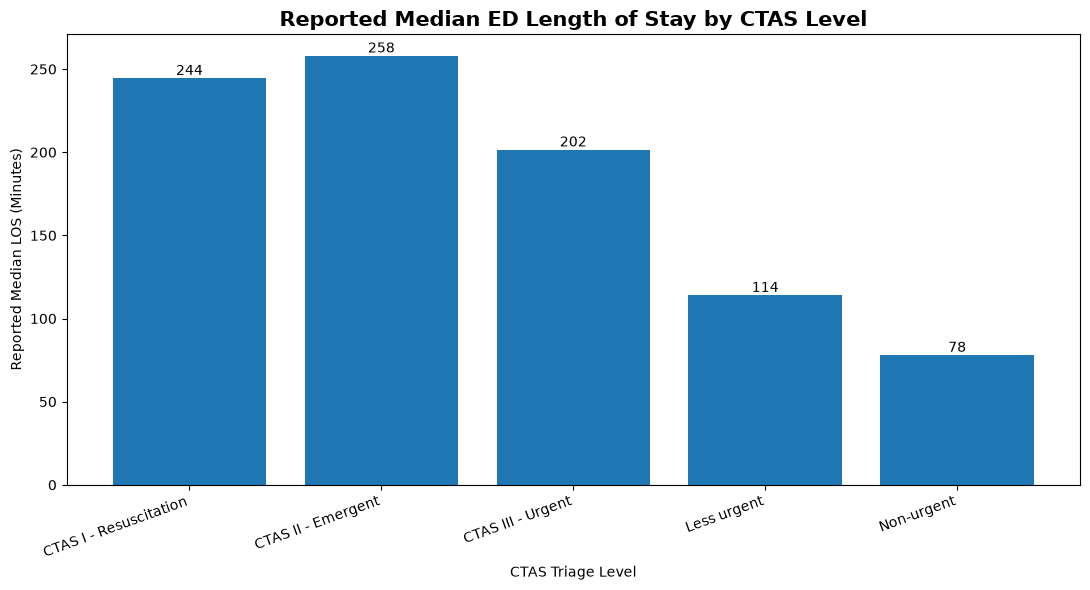

In [56]:
# ============================================================
# VISUALIZATION 1 — REPORTED MEDIAN ED LOS BY CTAS LEVEL (BAR)
# ============================================================

plot_data = (
    h1_summary
    .reindex(
        VALID_CTAS_LEVELS
    )
)

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    VALID_CTAS_LEVELS,
    plot_data[
        "Median_Reported_LOS"
    ]
)

plt.title(
    "Reported Median ED Length of Stay by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.xticks(
    rotation=20,
    ha="right"
)

for bar, value in zip(
    bars,
    plot_data[
        "Median_Reported_LOS"
    ]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

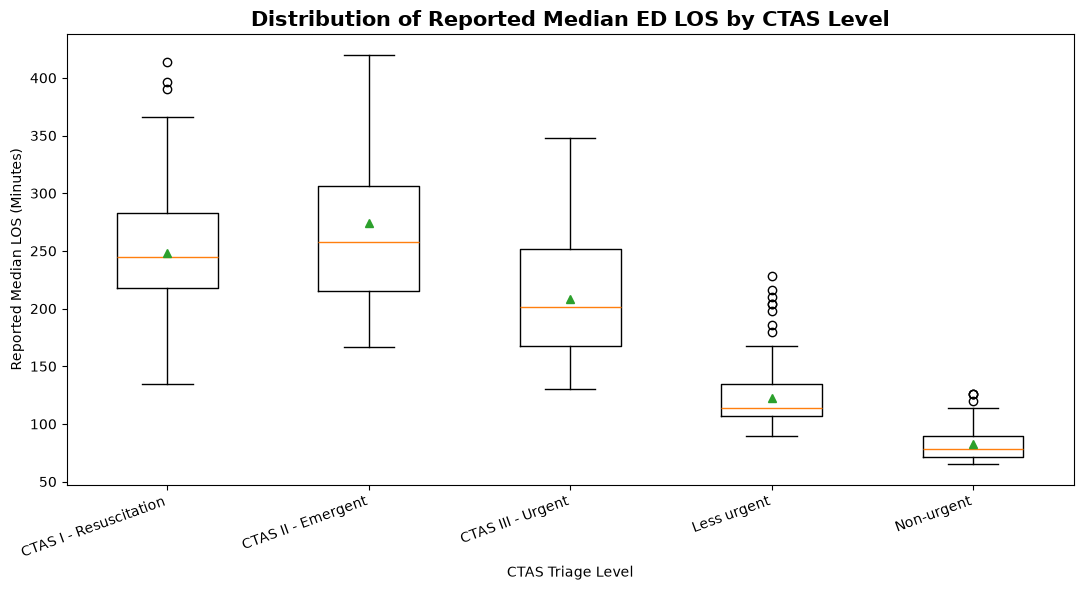

In [57]:
# ============================================================
# VISUALIZATION 2 — DISTRIBUTION OF MATCHED LOS (BOXPLOT)
# ============================================================
# Uses the complete Friedman matrix (matched blocks).

plt.figure(
    figsize=(11, 6)
)

plt.boxplot(
    [
        complete_matrix[level].to_numpy()
        for level in VALID_CTAS_LEVELS
    ],
    tick_labels=VALID_CTAS_LEVELS,
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

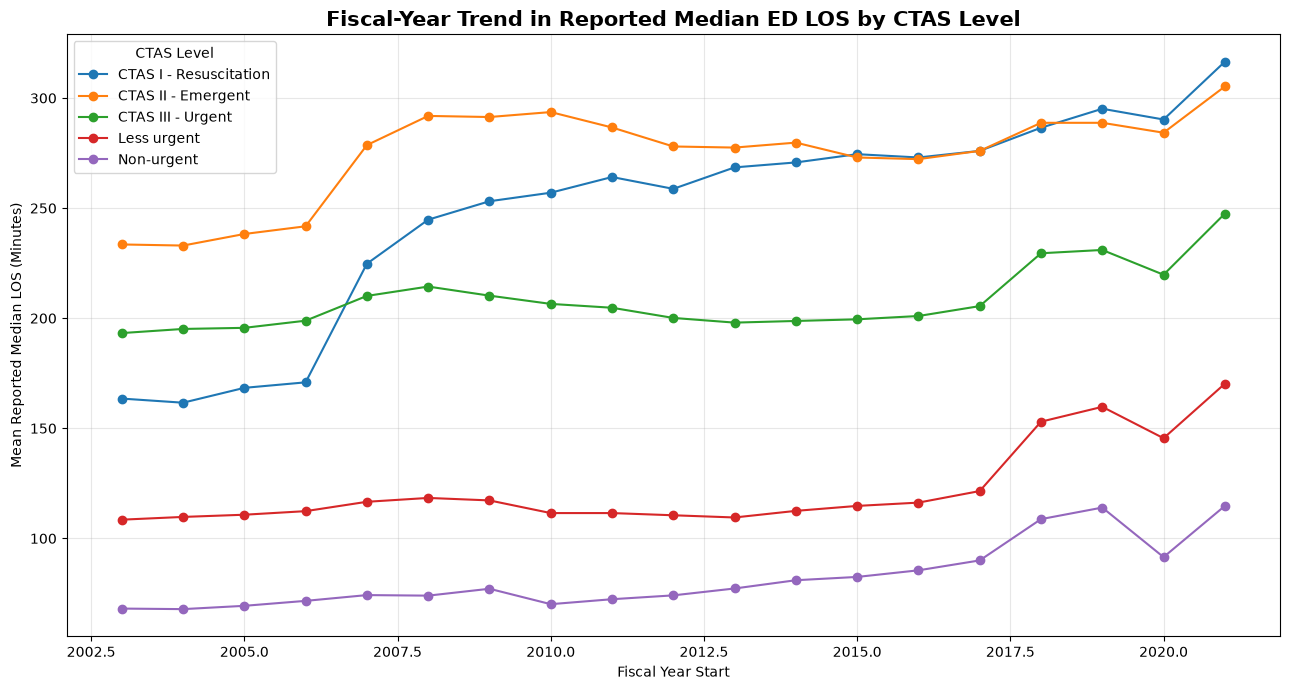

In [58]:
# ============================================================
# VISUALIZATION 3 — FISCAL-YEAR TREND (LINE CHART)
# ============================================================
# Descriptive only; not a second hypothesis test.

year_ctas = (
    h1_df
    .groupby(
        [
            "fiscal_year_start",
            "triage_level"
        ],
        observed=True
    )[
        "median_los_minutes"
    ]
    .mean()
    .reset_index(
        name="mean_reported_median_los"
    )
)

plt.figure(
    figsize=(13, 7)
)

for level in VALID_CTAS_LEVELS:

    subset = year_ctas[
        year_ctas[
            "triage_level"
        ] == level
    ]

    if subset.empty:
        continue

    plt.plot(
        subset[
            "fiscal_year_start"
        ],
        subset[
            "mean_reported_median_los"
        ],
        marker="o",
        label=level
    )

plt.title(
    "Fiscal-Year Trend in Reported Median ED LOS by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "Mean Reported Median LOS (Minutes)"
)

plt.legend(
    title="CTAS Level"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

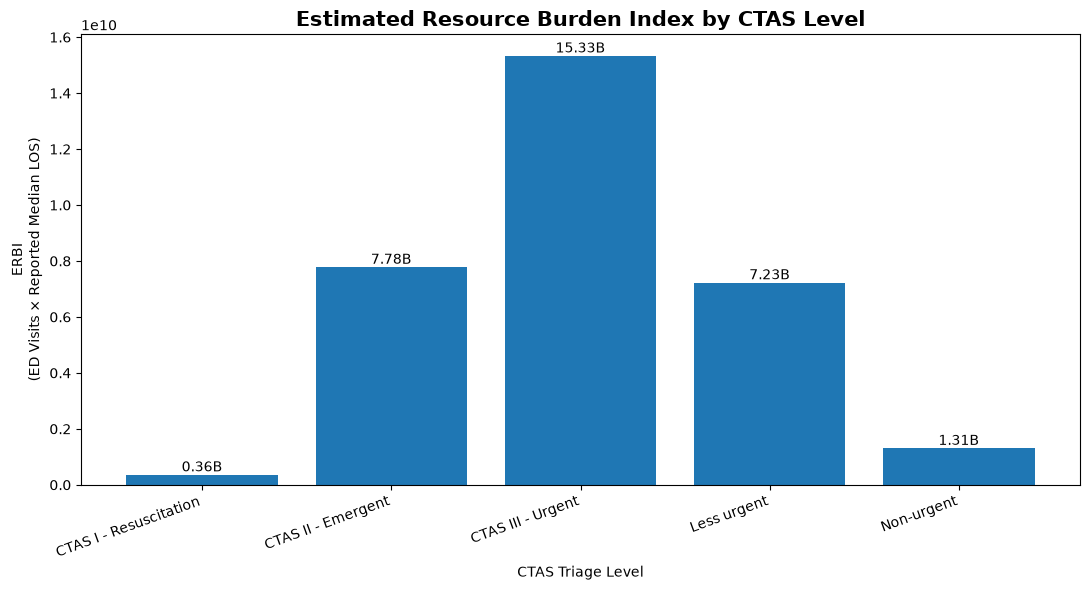

In [59]:
# ============================================================
# VISUALIZATION 4 — ERBI (ESTIMATED RESOURCE BURDEN INDEX)
# ============================================================
# ERBI is a resource-burden proxy and is NOT actual total ED minutes.
# ed_visits is used only for this descriptive/resource calculation,
# NOT as a statistical frequency weight.

h1_erbi = (
    h1_df
    .assign(
        ERBI=
            h1_df["ed_visits"]
            *
            h1_df["median_los_minutes"]
    )
    .groupby(
        "triage_level",
        observed=True
    )["ERBI"]
    .sum()
    .reindex(
        VALID_CTAS_LEVELS
    )
)

plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    VALID_CTAS_LEVELS,
    h1_erbi.values
)

plt.title(
    "Estimated Resource Burden Index by CTAS Level",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "CTAS Triage Level"
)

plt.ylabel(
    "ERBI\n"
    "(ED Visits × Reported Median LOS)"
)

plt.xticks(
    rotation=20,
    ha="right"
)

for bar, value in zip(
    bars,
    h1_erbi.values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1e9:.2f}B",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# FINAL H1 RESULT TABLE
# ============================================================

h1_results = pd.DataFrame({

    "Hypothesis": [
        "H1"
    ],

    "Research_Question": [
        "Does reported median ED LOS differ across CTAS triage levels?"
    ],

    "Primary_Test": [
        "Friedman test"
    ],

    "Friedman_Chi_Square": [
        friedman_statistic
    ],

    "Degrees_of_Freedom": [
        degrees_of_freedom
    ],

    "P_Value": [
        p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "Kendalls_W": [
        kendalls_w
    ],

    "Decision": [
        decision
    ]
})

print("=" * 90)
print("H1 — FINAL HYPOTHESIS TEST RESULTS")
print("=" * 90)

display(
    h1_results.round(6)
)

H1 — FINAL HYPOTHESIS TEST RESULTS


,Hypothesis,Research_Question,Primary_Test,Friedman_Chi_Square,Degrees_of_Freedom,P_Value,Alpha,Kendalls_W,Decision
0,H1,Does reported median ED LOS differ across CTAS...,Friedman test,552.8801,4,0.0000,0.0500,0.9093,Reject H₀


In [61]:
# ============================================================
# FINAL HUMAN-READABLE RESULT
# ============================================================

print("=" * 90)
print("FINAL H1 RESULT")
print("=" * 90)

print(
    "\nResearch Question:"
)

print(
    "Does reported median ED length of stay differ "
    "across CTAS triage levels?"
)

print(
    "\nPrimary test:"
)

print(
    "Friedman test for matched aggregate observations."
)

print(
    f"\nχ²({degrees_of_freedom}) = "
    f"{friedman_statistic:.4f}"
)

print(
    f"p = {p_value:.10g}"
)

print(
    f"Kendall's W = "
    f"{kendalls_w:.4f}"
)

print(
    f"\nDecision: {decision}"
)

print(
    f"\nConclusion:\n{conclusion}"
)

print(
    "\nMethodological limitation:"
)

print(
    "The analysis uses pre-aggregated NACRS-derived "
    "observations. The matched blocks are defined by "
    "fiscal year, sex, age group, and population category. "
    "The findings therefore represent aggregate-level "
    "associations and should not be interpreted as "
    "individual-patient effects or causal relationships."
)

print("\n" + "=" * 90)
print("CAPSTONE INTERPRETATION")
print("=" * 90)

print(
    f"\nA Friedman test was conducted to determine whether reported median "
    f"emergency-department length of stay differed across CTAS triage levels "
    f"within matched aggregate strata defined by fiscal year, sex, age group, "
    f"and population category. The test indicated a statistically significant "
    f"difference across the five CTAS categories, χ²({degrees_of_freedom}) = "
    f"{friedman_statistic:.4f}, p < .001, with Kendall's W = {kendalls_w:.4f}. "
    f"Therefore, the null hypothesis was rejected. Pairwise Wilcoxon signed-rank "
    f"tests with Bonferroni correction were subsequently used to identify the "
    f"CTAS categories contributing to the overall difference. Because the NACRS "
    f"data are pre-aggregated, these findings represent aggregate-level "
    f"associations and should not be interpreted as individual-patient effects "
    f"or causal relationships."
)

FINAL H1 RESULT

Research Question:
Does reported median ED length of stay differ across CTAS triage levels?

Primary test:
Friedman test for matched aggregate observations.

χ²(4) = 552.8801
p = 2.436574491e-118
Kendall's W = 0.9093

Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs across CTAS triage levels within the matched aggregate strata.

Methodological limitation:
The analysis uses pre-aggregated NACRS-derived observations. The matched blocks are defined by fiscal year, sex, age group, and population category. The findings therefore represent aggregate-level associations and should not be interpreted as individual-patient effects or causal relationships.

CAPSTONE INTERPRETATION

A Friedman test was conducted to determine whether reported median emergency-department length of stay differed across CTAS triage levels within matched aggregate strata defined by fiscal year, sex, age group, and population cat

In [62]:
# ============================================================
# AGGREGATE STRUCTURE VALIDATION SUMMARY
# ============================================================

print("=" * 80)
print("AGGREGATE STRUCTURE VALIDATION SUMMARY")
print("=" * 80)

print(
    f"Matched aggregate blocks : {len(complete_matrix):,}"
)

print(
    f"CTAS levels per block    : {k_groups}"
)

print(
    f"Friedman matrix shape    : {complete_matrix.shape}"
)

print(
    f"Friedman chi-square      : {friedman_statistic:.4f}"
)

print(
    f"Degrees of freedom       : {degrees_of_freedom}"
)

print(
    f"p-value                  : {p_value:.10g}"
)

print(
    f"Kendall's W              : {kendalls_w:.4f}"
)

print(
    f"Decision                 : {decision}"
)

print(
    f"Post-hoc comparisons     : {len(posthoc):,}"
)

if not posthoc.empty:
    sig_count = posthoc["Significant"].sum()
    print(
        f"Significant pairs        : {sig_count:,} of {len(posthoc):,}"
    )

AGGREGATE STRUCTURE VALIDATION SUMMARY
Matched aggregate blocks : 152
CTAS levels per block    : 5
Friedman matrix shape    : (152, 5)
Friedman chi-square      : 552.8801
Degrees of freedom       : 4
p-value                  : 2.436574491e-118
Kendall's W              : 0.9093
Decision                 : Reject H₀
Post-hoc comparisons     : 10
Significant pairs        : 10 of 10


In [65]:
import numpy as np
import pandas as pd

from scipy.stats import (
    friedmanchisquare,
    wilcoxon
)

# ------------------------------------------------------------
# 1. CTAS LEVELS
# ------------------------------------------------------------

VALID_CTAS_LEVELS = [
    "CTAS I - Resuscitation",
    "CTAS II - Emergent",
    "CTAS III - Urgent",
    "Less urgent",
    "Non-urgent"
]

ALPHA = 0.05


# ------------------------------------------------------------
# 2. MAKE SURE h1_df EXISTS
# ------------------------------------------------------------

if "h1_df" not in globals():

    if "ctas_df" not in globals():

        raise NameError(
            "Neither h1_df nor ctas_df exists. "
            "Run the CTAS data-loading/cleaning cell first."
        )

    h1_df = ctas_df.copy()


# ------------------------------------------------------------
# 3. STANDARDIZE REQUIRED VARIABLES
# ------------------------------------------------------------

h1_df["median_los_minutes"] = pd.to_numeric(
    h1_df["median_los_minutes"],
    errors="coerce"
)

h1_df["ed_visits"] = pd.to_numeric(
    h1_df["ed_visits"],
    errors="coerce"
)


# ------------------------------------------------------------
# 4. KEEP ONLY VALID CTAS LEVELS
# ------------------------------------------------------------

h1_df = h1_df[
    h1_df["triage_level"].isin(
        VALID_CTAS_LEVELS
    )
].copy()


# ------------------------------------------------------------
# 5. REMOVE INVALID LOS VALUES
# ------------------------------------------------------------

h1_df = h1_df[
    h1_df["median_los_minutes"].notna()
].copy()

h1_df = h1_df[
    h1_df["median_los_minutes"] >= 0
].copy()


# ------------------------------------------------------------
# 6. CREATE MATCHED BLOCK
# ------------------------------------------------------------

BLOCK_COLUMNS = [
    "fiscal_year",
    "fiscal_year_start",
    "sex",
    "age_group",
    "population_category"
]

missing_block_columns = [
    column
    for column in BLOCK_COLUMNS
    if column not in h1_df.columns
]

if missing_block_columns:

    raise ValueError(
        "Missing aggregation columns: "
        + ", ".join(missing_block_columns)
    )


h1_df["block_id"] = (
    h1_df[
        BLOCK_COLUMNS
    ]
    .astype(str)
    .agg(
        "|".join,
        axis=1
    )
)


# ------------------------------------------------------------
# 7. CHECK DUPLICATES
# ------------------------------------------------------------

duplicate_mask = (
    h1_df
    .duplicated(
        subset=[
            "block_id",
            "triage_level"
        ],
        keep=False
    )
)

if duplicate_mask.any():

    raise ValueError(
        "Duplicate block × CTAS combinations detected."
    )


# ------------------------------------------------------------
# 8. CREATE FRIEDMAN MATRIX
# ------------------------------------------------------------

friedman_matrix = (
    h1_df
    .pivot(
        index="block_id",
        columns="triage_level",
        values="median_los_minutes"
    )
    .reindex(
        columns=VALID_CTAS_LEVELS
    )
)


# ------------------------------------------------------------
# 9. KEEP COMPLETE MATCHED BLOCKS
# ------------------------------------------------------------

complete_matrix = (
    friedman_matrix
    .dropna(
        how="any"
    )
)


if len(complete_matrix) < 2:

    raise ValueError(
        "Not enough complete matched blocks "
        "for the Friedman test."
    )


# ------------------------------------------------------------
# 10. FRIEDMAN TEST
# ------------------------------------------------------------

friedman_statistic, p_value = friedmanchisquare(
    *[
        complete_matrix[level].to_numpy()
        for level in VALID_CTAS_LEVELS
    ]
)


degrees_of_freedom = (
    len(VALID_CTAS_LEVELS) - 1
)


# ------------------------------------------------------------
# 11. KENDALL'S W
# ------------------------------------------------------------

n_blocks = len(complete_matrix)

k_groups = len(VALID_CTAS_LEVELS)

kendalls_w = (
    friedman_statistic
    /
    (
        n_blocks
        * (k_groups - 1)
    )
)


# ------------------------------------------------------------
# 12. HYPOTHESIS DECISION
# ------------------------------------------------------------

if p_value < ALPHA:

    decision = "Reject H₀"

    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "across CTAS triage levels within the matched "
        "aggregate strata."
    )

else:

    decision = "Fail to Reject H₀"

    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs across CTAS triage levels "
        "within the matched aggregate strata."
    )


# ------------------------------------------------------------
# 13. POST-HOC WILCOXON TESTS
# ------------------------------------------------------------

from itertools import combinations

pairwise_results = []


if p_value < ALPHA:

    for group1, group2 in combinations(
        VALID_CTAS_LEVELS,
        2
    ):

        x = complete_matrix[group1]

        y = complete_matrix[group2]

        statistic, raw_p = wilcoxon(
            x,
            y,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )

        pairwise_results.append({

            "Group_1": group1,

            "Group_2": group2,

            "Wilcoxon_Statistic": statistic,

            "Raw_P_Value": raw_p
        })


posthoc = pd.DataFrame(
    pairwise_results
)


# ------------------------------------------------------------
# 14. BONFERRONI CORRECTION
# ------------------------------------------------------------

if not posthoc.empty:

    number_comparisons = len(posthoc)

    posthoc["Adjusted_P_Value"] = (
        posthoc["Raw_P_Value"]
        * number_comparisons
    ).clip(
        upper=1
    )

    posthoc["Significant"] = (
        posthoc["Adjusted_P_Value"]
        < ALPHA
    )

    posthoc = (
        posthoc
        .sort_values(
            "Adjusted_P_Value"
        )
        .reset_index(
            drop=True
        )
    )


# ------------------------------------------------------------
# 15. FINAL H1 RESULTS TABLE
# ------------------------------------------------------------

h1_results = pd.DataFrame({

    "Hypothesis": [
        "H1"
    ],

    "Research_Question": [
        "Does reported median ED LOS differ across CTAS triage levels?"
    ],

    "Primary_Test": [
        "Friedman test"
    ],

    "Friedman_Chi_Square": [
        friedman_statistic
    ],

    "Degrees_of_Freedom": [
        degrees_of_freedom
    ],

    "P_Value": [
        p_value
    ],

    "Alpha": [
        ALPHA
    ],

    "Kendalls_W": [
        kendalls_w
    ],

    "Decision": [
        decision
    ]
})


# ------------------------------------------------------------
# 16. PRINT SUMMARY
# ------------------------------------------------------------

print("=" * 80)
print("H1 ANALYSIS VARIABLES SUCCESSFULLY CREATED")
print("=" * 80)

print(
    f"Matched blocks       : {len(complete_matrix):,}"
)

print(
    f"CTAS groups          : {k_groups}"
)

print(
    f"Friedman χ²          : {friedman_statistic:.6f}"
)

print(
    f"Degrees of freedom   : {degrees_of_freedom}"
)

print(
    f"P-value              : {p_value:.10g}"
)

print(
    f"Kendall's W          : {kendalls_w:.6f}"
)

print(
    f"Decision             : {decision}"
)

print(
    "\nAll H1 variables are now available."
)

H1 ANALYSIS VARIABLES SUCCESSFULLY CREATED
Matched blocks       : 152
CTAS groups          : 5
Friedman χ²          : 552.880105
Degrees of freedom   : 4
P-value              : 2.436574491e-118
Kendall's W          : 0.909342
Decision             : Reject H₀

All H1 variables are now available.


In [66]:
display(
    posthoc.round(6)
)

,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,Less urgent,Non-urgent,0.0000,0.0000,0.0000,True
1,CTAS II - Emergent,CTAS III - Urgent,0.0000,0.0000,0.0000,True
2,CTAS I - Resuscitation,Less urgent,0.0000,0.0000,0.0000,True
3,CTAS III - Urgent,Less urgent,0.0000,0.0000,0.0000,True
4,CTAS III - Urgent,Non-urgent,0.0000,0.0000,0.0000,True
5,CTAS I - Resuscitation,Non-urgent,0.0000,0.0000,0.0000,True
6,CTAS II - Emergent,Less urgent,0.0000,0.0000,0.0000,True
7,CTAS II - Emergent,Non-urgent,0.0000,0.0000,0.0000,True
8,CTAS I - Resuscitation,CTAS III - Urgent,"1,781.5000",0.0000,0.0000,True
9,CTAS I - Resuscitation,CTAS II - Emergent,"3,157.0000",0.0000,0.0001,True


In [68]:
expected_pairs = {
    tuple(sorted(pair))
    for pair in combinations(
        VALID_CTAS_LEVELS,
        2
    )
}

actual_pairs = {
    tuple(sorted([
        row["Group_1"],
        row["Group_2"]
    ]))
    for _, row in posthoc.iterrows()
}

missing_pairs = (
    expected_pairs
    - actual_pairs
)

print("=" * 80)
print("POST-HOC PAIRWISE COMPLETENESS CHECK")
print("=" * 80)

print(
    f"Expected comparisons : {len(expected_pairs)}"
)

print(
    f"Actual comparisons   : {len(actual_pairs)}"
)

print(
    f"Missing comparisons  : {len(missing_pairs)}"
)

if missing_pairs:

    print("\nMissing pairs:")

    for pair in sorted(missing_pairs):

        print(
            f"  - {pair[0]} vs {pair[1]}"
        )

else:

    print(
        "\n✓ All 10 pairwise comparisons are present."
    )

POST-HOC PAIRWISE COMPLETENESS CHECK
Expected comparisons : 10
Actual comparisons   : 10
Missing comparisons  : 0

✓ All 10 pairwise comparisons are present.


In [70]:
display(
    posthoc[
        [
            "Group_1",
            "Group_2",
            "Wilcoxon_Statistic",
            "Raw_P_Value",
            "Adjusted_P_Value",
            "Significant"
        ]
    ].round(10)
)

,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,Less urgent,Non-urgent,0.0000,0.0000,0.0000,True
1,CTAS II - Emergent,CTAS III - Urgent,0.0000,0.0000,0.0000,True
2,CTAS I - Resuscitation,Less urgent,0.0000,0.0000,0.0000,True
3,CTAS III - Urgent,Less urgent,0.0000,0.0000,0.0000,True
4,CTAS III - Urgent,Non-urgent,0.0000,0.0000,0.0000,True
5,CTAS I - Resuscitation,Non-urgent,0.0000,0.0000,0.0000,True
6,CTAS II - Emergent,Less urgent,0.0000,0.0000,0.0000,True
7,CTAS II - Emergent,Non-urgent,0.0000,0.0000,0.0000,True
8,CTAS I - Resuscitation,CTAS III - Urgent,"1,781.5000",0.0000,0.0000,True
9,CTAS I - Resuscitation,CTAS II - Emergent,"3,157.0000",0.0000,0.0001,True
